# Heart Disease Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether a person has heart disease or not.

In [21]:
import pandas as pd
import numpy as np
HeartDiseaseData=pd.read_csv("C:/Users/Ankit Raut/Python ML/Python IVY Feb-2024 (1)/Python IVY Feb-2024/Python Datasets/Classification Datasets/My Projects/heart.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',HeartDiseaseData.shape)
HeartDiseaseData.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',HeartDiseaseData.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None) 
HeartDiseaseData.head()

Data Before deleting duplicate values: (918, 12)
Data After:deleting duplicate values (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Target Variable:HeartDisease

<Axes: xlabel='HeartDisease'>

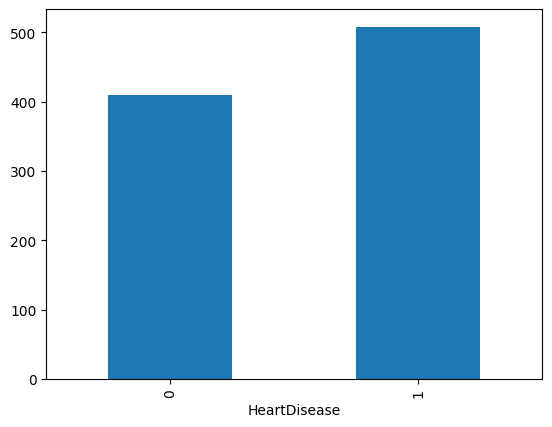

In [22]:
HeartDiseaseData.groupby('HeartDisease').size().plot(kind='bar')

In [23]:
HeartDiseaseData.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [24]:
HeartDiseaseData.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

## CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope', 'HeartDisease']
## ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']

In [25]:
HeartDiseaseData.shape

(918, 12)

In [26]:
HeartDiseaseData.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [27]:
HeartDiseaseData.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


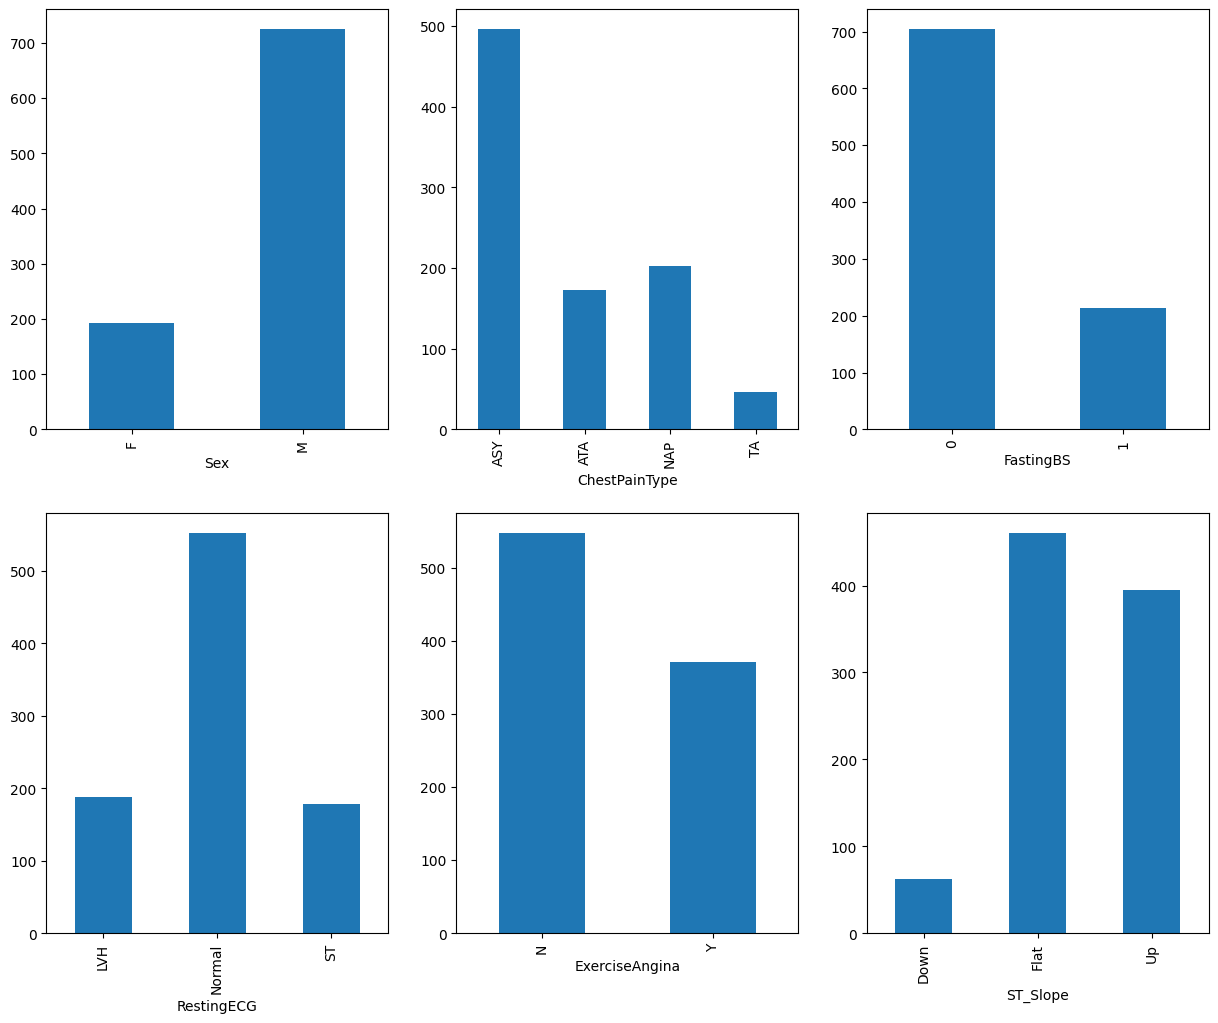

In [28]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_columns in zip(CategoricalCols,range(len(CategoricalCols))):
    HeartDiseaseData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_columns])

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>, <Axes: >]], dtype=object)

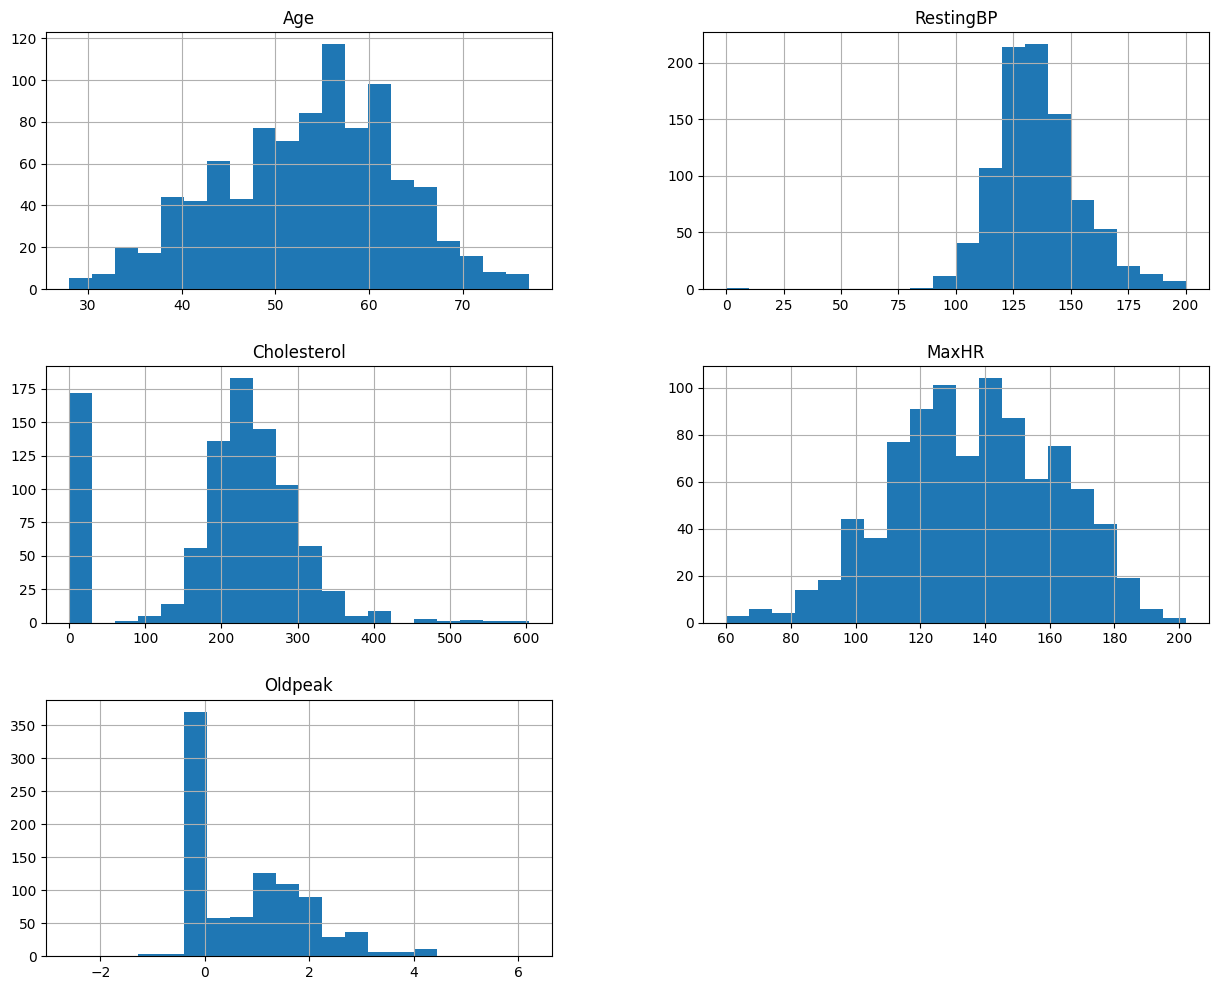

In [29]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
HeartDiseaseData[ContinousCols].hist(bins=20,figsize=(15,12))

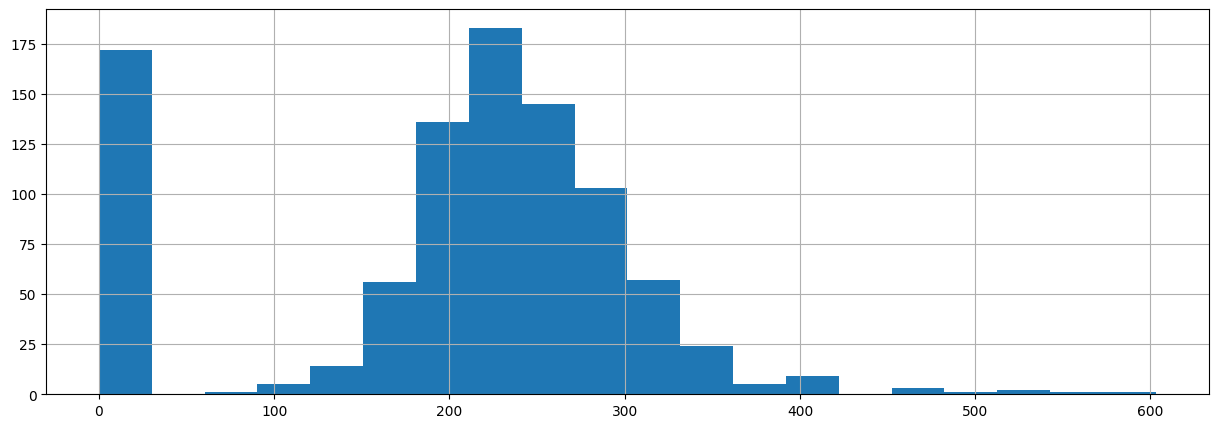

In [30]:

HeartDiseaseData['Cholesterol'].hist(bins=20,figsize=(15,5))
HeartDiseaseData.loc[HeartDiseaseData['Cholesterol']>418,'Cholesterol']=417

In [31]:
HeartDiseaseData.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

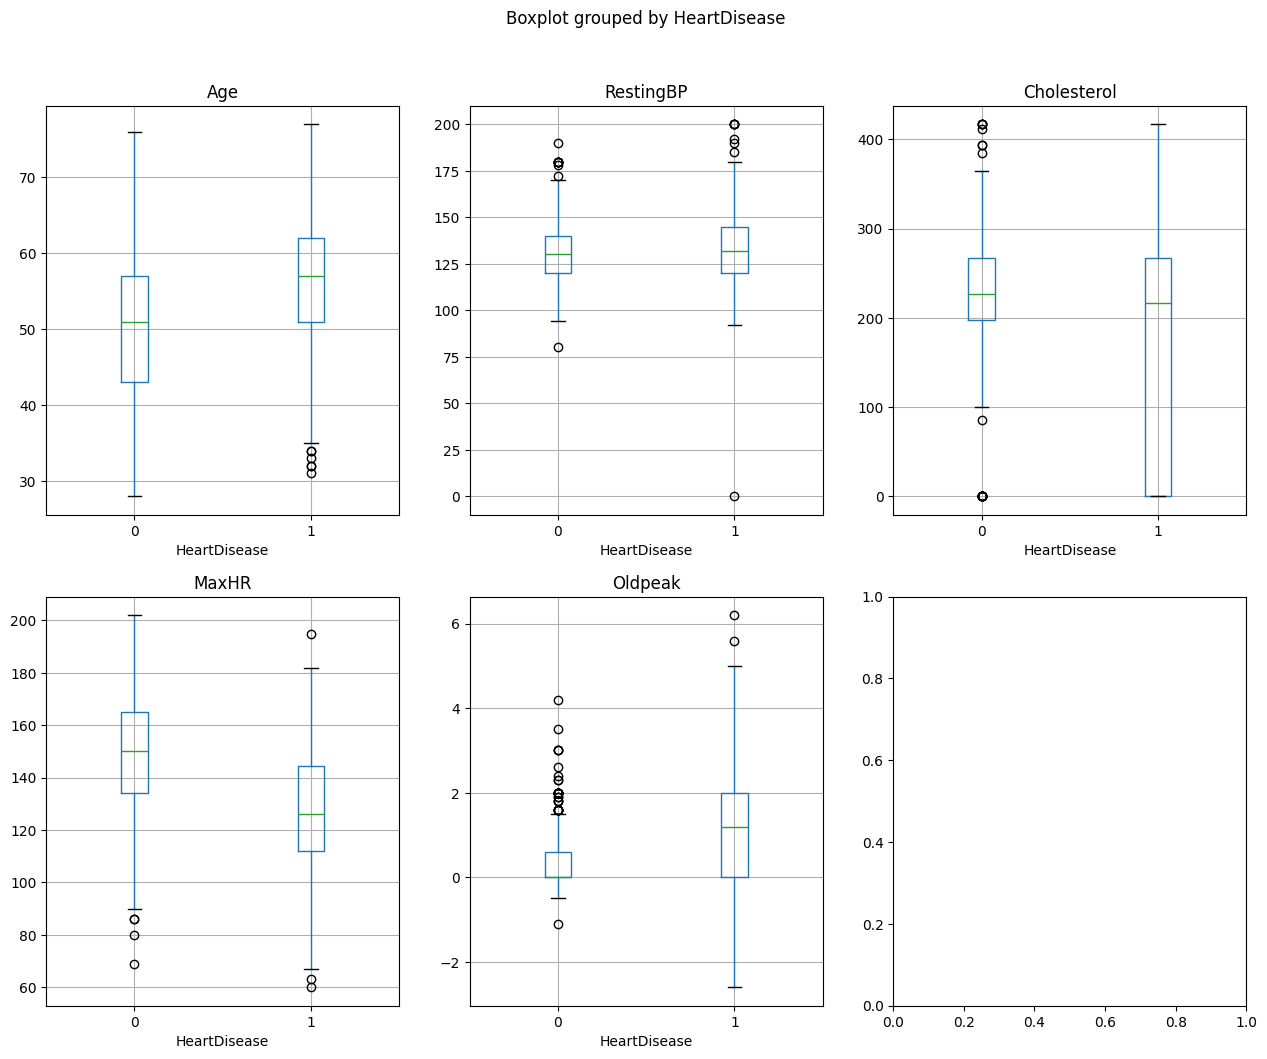

In [32]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    HeartDiseaseData.boxplot(column=cols,by='HeartDisease',vert=True,ax=subplots[no_of_cols])


In [33]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
SelectedPredictors=[]
from scipy.stats import f_oneway

for cols in ContinousCols:
    CategoricalGroupLists=HeartDiseaseData.groupby(cols)['HeartDisease'].apply(list)
    AnovaResults=f_oneway(*CategoricalGroupLists)
    if AnovaResults[1]<0.05:
        print(cols,' is corelated with HeartDisease and P values is:',AnovaResults[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not corelated with HeartDisease and P values is:',AnovaResults[1])
print(SelectedPredictors)
        
        

Age  is corelated with HeartDisease and P values is: 2.210523049940782e-09
RestingBP  is corelated with HeartDisease and P values is: 0.011298150619295956
Cholesterol  is corelated with HeartDisease and P values is: 1.275389750298296e-08
MaxHR  is corelated with HeartDisease and P values is: 8.761081954678646e-13
Oldpeak  is corelated with HeartDisease and P values is: 6.24095533400621e-29
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


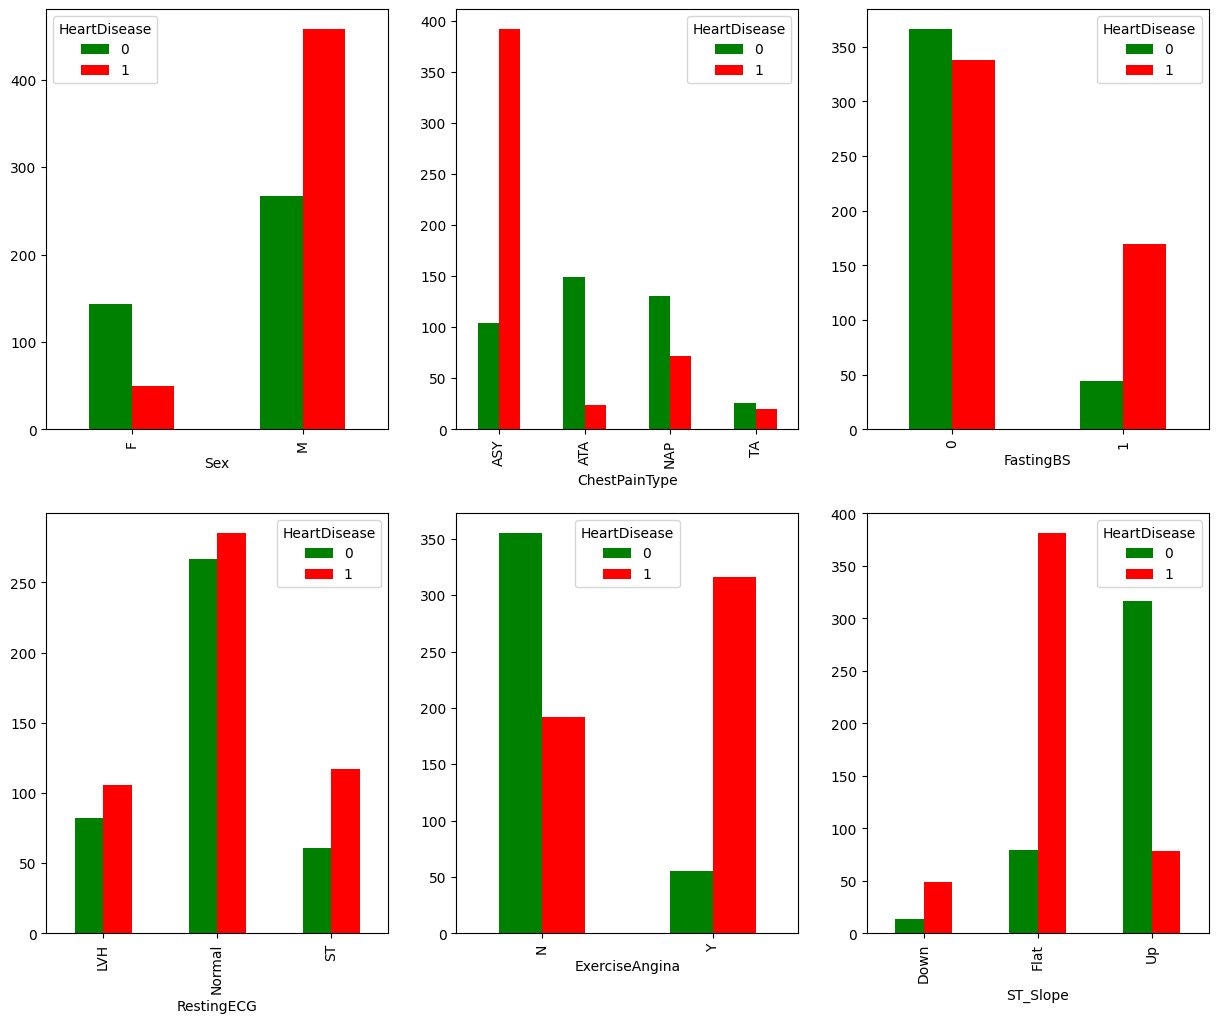

In [34]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']

import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=HeartDiseaseData['HeartDisease'],index=HeartDiseaseData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])


In [35]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']
SelectedPredictors=[]
from  scipy.stats  import chi2_contingency
for  cols in CategoricalCols:
    crosstabresults=pd.crosstab(columns=HeartDiseaseData['HeartDisease'],index=HeartDiseaseData[cols]) 
    chi2_results=chi2_contingency(crosstabresults) 
    if chi2_results[1]<0.05:
        print(cols,' is correlated with HeartDisease and p value is:',chi2_results[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with HeartDisease and p value is:',chi2_results[1])
SelectedPredictors

Sex  is correlated with HeartDisease and p value is: 4.597617450809164e-20
ChestPainType  is correlated with HeartDisease and p value is: 8.08372842808765e-58
FastingBS  is correlated with HeartDisease and p value is: 1.0573018731809955e-15
RestingECG  is correlated with HeartDisease and p value is: 0.0042292328167544925
ExerciseAngina  is correlated with HeartDisease and p value is: 2.907808387659878e-50
ST_Slope  is correlated with HeartDisease and p value is: 5.167637689470128e-78


['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope']

In [36]:
SelectedColumns=['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

DataForMLHeartDiseaseData=HeartDiseaseData[SelectedColumns] 
DataForMLHeartDiseaseData.to_pickle('DataForMLHeartDiseaseData.pkl')
DataForMLHeartDiseaseData=pd.read_pickle('DataForMLHeartDiseaseData.pkl')
DataForMLHeartDiseaseData_Numeric=pd.get_dummies(DataForMLHeartDiseaseData)
DataForMLHeartDiseaseData_Numeric.head()


,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0,40,140,289,172,0.0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,0,49,160,180,156,1.0,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,0,37,130,283,98,0.0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,0,48,138,214,108,1.5,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,0,54,150,195,122,0.0,False,True,False,False,True,False,False,True,False,True,False,False,False,True


In [37]:
DataForMLHeartDiseaseData_Numeric.replace({False:0,True:1},inplace=True).head()

,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0,40,140,289,172,0.0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,0,49,160,180,156,1.0,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,0,37,130,283,98,0.0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,0,48,138,214,108,1.5,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0,54,150,195,122,0.0,0,1,0,0,1,0,0,1,0,1,0,0,0,1


In [38]:
DataForMLHeartDiseaseData_Numeric.columns

Index(['FastingBS', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [39]:
DataForMLHeartDiseaseData_Numeric['HeartDisease']=HeartDiseaseData['HeartDisease']

In [54]:
predictors=['FastingBS', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
#'Age','RestingBP','Oldpeak','Sex_M'
#predictors=[ 'Oldpeak',
 #   'ChestPainType_ASY', 'ST_Slope_Up'] 
targetVariable='HeartDisease'
X=DataForMLHeartDiseaseData_Numeric[predictors].values
y=DataForMLHeartDiseaseData_Numeric[targetVariable].values
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.1666,random_state=5)

In [41]:
X_train[0:5]

array([[1.3, 1, 0],
       [3.5, 0, 0],
       [0.0, 0, 1],
       [0.0, 0, 0],
       [0.8, 0, 1]], dtype=object)

In [42]:
y_train[0:5]

array([1, 1, 0, 0, 0])

In [55]:
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=6,scoring='f1_weighted')
print(AccuracyValues)
print(np.mean(AccuracyValues))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88        58
           1       0.94      0.92      0.93        95

    accuracy                           0.91       153
   macro avg       0.90      0.91      0.90       153
weighted avg       0.91      0.91      0.91       153

[[52  6]
 [ 8 87]]
Sample Data Accuracy: 0.91
[0.85643037 0.89554183 0.89381228 0.84502329 0.83028525 0.77834797]
0.8499068318342303


Sample Data Accuaracy: 0.85
[0.89527105 0.79738562 0.8694502  0.85449735 0.78486998 0.732511  ]
0.8223308656825763


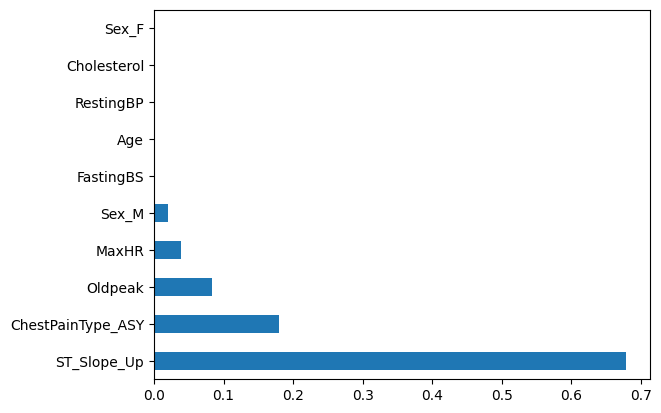

In [56]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
#print(metrics.classification_report(y_test,prediction))
#print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2))
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=6,scoring='f1_weighted')
print(AccuracyValues)
print(np.mean(AccuracyValues))

# Selected Logistic Rgression Model for Deployment

## Deploying on Sample Production Data

In [48]:
X

array([[0.0, 0, 1],
       [1.0, 0, 0],
       [0.0, 0, 1],
       ...,
       [1.2, 1, 0],
       [0.0, 0, 0],
       [0.0, 0, 1]], shape=(918, 3), dtype=object)

In [49]:
NewData=pd.DataFrame(data=[[0,0,1],
                           [1,1,0],
                           [1.2,0,1]], columns=predictors)
NewData

,Oldpeak,ChestPainType_ASY,ST_Slope_Up
0,0.0,0,1
1,1.0,1,0
2,1.2,0,1


In [50]:
newX=NewData.values

In [51]:
LOG.predict(newX)

array([0, 1, 0])

In [52]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=DTree.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [53]:
GenerateSurvialPred(inpData=NewData)

,Oldpeak,ChestPainType_ASY,ST_Slope_Up,Prediction
0,0.0,0,1,0
1,1.0,1,0,1
2,1.2,0,1,0
